# Function 6: 5D Composite Constraint Optimisation
**Programme:** Imperial College London – Professional Certificate in Machine Learning & AI  
**Domain Context:** Dairy Total Mixed Ration (TMR) Diet Formulation (5 Feed Proportions)  
**Author:** Dr. Joseph Neary  

---

## 1. Problem Framing & Objective
Function 6 accepts a 5D feature vector $\mathbf{x} = (x_1, x_2, x_3, x_4, x_5)$ bounded within $[0, 1]^5$. The objective is to **maximise** a composite score $y$ (where negative penalties are structured such that optimal performance pushes the output as close to zero as possible).

We build a **Gaussian Process (GP) Surrogate Model** using an RBF kernel with target normalization (`normalize_y=True`) and noise regularization ($\alpha = 10^{-3}$). We evaluate candidate utility across a $15 \times 15 \times 15 \times 15 \times 15$ grid ($759,375$ points) using the **Upper Confidence Bound (UCB)** acquisition function.

## 2. Ingestion & Baseline Data Analysis
We ingest the $N = 10$ seed observations provided in `Data/Raw/function_6/` and display them sorted by descending target output $y$.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# ==========================================
# 1. LOAD DATA FROM YOUR RAW DATA DIRECTORY
# ==========================================
base_dir = r"C:\Projects\ML\capstone\Imperial-ML-Capstone-Project"

input_path = os.path.join(base_dir, 'Data', 'Raw', 'function_6', 'initial_inputs.npy')
output_path = os.path.join(base_dir, 'Data', 'Raw', 'function_6', 'initial_outputs.npy')

X_init = np.load(input_path)   # Shape: (10, 5) - 5D input coordinates
y_init = np.load(output_path)  # Shape: (10,)   - Target score

# Display initial data table sorted by current peak score
df_f6 = pd.DataFrame(X_init, columns=['x1', 'x2', 'x3', 'x4', 'x5'])
df_f6['y'] = y_init

print("=== Function 6: Initial Observations (Sorted High to Low) ===")
print(df_f6.sort_values(by='y', ascending=False).reset_index(drop=True))
print("\n" + "="*60 + "\n")

=== Function 6: Initial Observations (Sorted High to Low) ===
          x1        x2        x3        x4        x5         y
0   0.728186  0.154693  0.732552  0.693997  0.056401 -0.714265
1   0.618812  0.331802  0.187288  0.756238  0.328835 -0.829237
2   0.782880  0.536336  0.443284  0.859700  0.010326 -0.935757
3   0.536797  0.308781  0.411879  0.388225  0.522528 -1.144785
4   0.242384  0.844100  0.577809  0.679021  0.501953 -1.209955
5   0.145111  0.896685  0.896322  0.726272  0.236272 -1.233786
6   0.784958  0.910682  0.708120  0.959225  0.004911 -1.247049
7   0.432166  0.715618  0.341819  0.705000  0.614962 -1.294247
8   0.757594  0.355831  0.016523  0.434207  0.112433 -1.309116
9   0.021735  0.428084  0.835939  0.489489  0.511082 -1.356682
10  0.770620  0.114404  0.046780  0.648324  0.273549 -1.536058
11  0.629308  0.803484  0.811408  0.045613  0.110624 -1.622839
12  0.729523  0.748106  0.679775  0.356552  0.671054 -1.672200
13  0.945069  0.288459  0.978806  0.961656  0.598016 -1.

## 3. GP Surrogate Fitting & 5D Grid Evaluation
We fit a non-parametric GP regressor with a composite RBF kernel:

$$k(\mathbf{x}, \mathbf{x}') = C \cdot \exp\left(-\frac{\|\mathbf{x} - \mathbf{x}'\|^2}{2\ell^2}\right)$$

We evaluate the **Upper Confidence Bound (UCB)** acquisition utility across the 5D lattice:

$$\text{UCB}(\mathbf{x}) = \mu(\mathbf{x}) + \kappa \cdot \sigma(\mathbf{x})$$

Where $\kappa = 2.0$ balances exploitation of high-performing diet configurations ($\mu$) with unmapped nutritional space exploration ($\sigma$).

In [2]:
# ==========================================
# 2. FIT GAUSSIAN PROCESS (GP) SURROGATE MODEL
# ==========================================
kernel = C(1.0, (1e-5, 1e5)) * RBF(length_scale=0.5, length_scale_bounds=(1e-3, 1e2))

gp = GaussianProcessRegressor(
    kernel=kernel, 
    n_restarts_optimizer=10, 
    alpha=1e-3,          # Regularization for noise tolerance
    normalize_y=True,    # Standardises target y values
    random_state=42
)

# Fit GP model to 5D inputs
gp.fit(X_init, y_init)

print("=== Fitted Kernel Hyperparameters ===")
print(gp.kernel_)
print("="*60 + "\n")

# ==========================================
# 3. 5D GRID SEARCH FOR UCB MAXIMISATION
# ==========================================
grid_res = 15  # 15^5 = 759,375 evaluation points
x_dom = np.linspace(0, 1, grid_res)

# Generate 5D meshgrid
X1, X2, X3, X4, X5 = np.meshgrid(x_dom, x_dom, x_dom, x_dom, x_dom)
X_test = np.column_stack([
    X1.ravel(), X2.ravel(), X3.ravel(), X4.ravel(), X5.ravel()
])

# Predict posterior mean and standard deviation across 5D space
mu, sigma = gp.predict(X_test, return_std=True)

# Upper Confidence Bound (UCB)
kappa = 2.0
ucb_values = mu + kappa * sigma

best_idx = np.argmax(ucb_values)
next_query = X_test[best_idx]

# ==========================================
# 4. PORTAL SUBMISSION FORMATTING
# ==========================================
formatted_coords = " - ".join([f"{coord:.6f}" for coord in next_query])

print("=== RECOMMENDED SUBMISSION FOR FUNCTION 6 (WEEK 1) ===")
print(f"Coordinates (x1 to x5): {list(next_query)}")
print(f"Portal Submission Format:  {formatted_coords}")
print("======================================================")

=== Fitted Kernel Hyperparameters ===
1.13**2 * RBF(length_scale=0.489)

=== RECOMMENDED SUBMISSION FOR FUNCTION 6 (WEEK 1) ===
Coordinates (x1 to x5): [np.float64(0.2857142857142857), np.float64(0.3571428571428571), np.float64(0.42857142857142855), np.float64(0.7142857142857142), np.float64(0.0)]
Portal Submission Format:  0.285714 - 0.357143 - 0.428571 - 0.714286 - 0.000000


## Imperial Capstone Reflection: Function 6 (Week 1)

**Query Input Coordinates:** `0.285714 - 0.357143 - 0.428571 - 0.714286 - 0.000000`

---

### 1. What method was used and why?
I implemented a **Gaussian Process (GP) Regression** surrogate model paired with an **Upper Confidence Bound (UCB)** acquisition function evaluated across a $15 \times 15 \times 15 \times 15 \times 15$ grid ($759,375$ candidate points) spanning the 5D unit hypercube $[0, 1]^5$.

A non-parametric GP surrogate model was selected because Function 6 represents a multi-variable composite score function where output penalties (flavor, consistency, cost, waste) are negative by design, requiring maximisation toward zero. We specified a composite Radial Basis Function (RBF) kernel:

$$k(\mathbf{x}, \mathbf{x}') = C \cdot \exp\left(-\frac{\|\mathbf{x} - \mathbf{x}'\|^2}{2\ell^2}\right)$$

Target normalization (`normalize_y=True`) and noise regularization ($\alpha = 10^{-3}$) were incorporated to stabilize hyperparameter estimation via Maximum Marginal Likelihood (MML). The fitted kernel converged to a variance scale of $C = 1.13^2$ and a length scale of $\ell = 0.489$.

---

### 2. Was the query focused on exploration or exploitation?
The query represents a **balanced exploration-exploitation strategy** governed by setting $\kappa = 2.0$ in the UCB acquisition utility formula:

$$\text{UCB}(\mathbf{x}) = \mu(\mathbf{x}) + \kappa \cdot \sigma(\mathbf{x})$$

In a 5D feature domain with only $N = 10$ seed observations, the volume of the search space creates extreme data sparsity. Pure exploitation ($\kappa = 0$) risks trapping the search in a sub-optimal local neighborhood. Setting $\kappa = 2.0$ mathematically weights high predicted performance ($\mu(\mathbf{x})$) while prioritizing candidate points in regions where epistemic uncertainty ($\sigma(\mathbf{x})$) remains high across the 5D lattice.

---

### 3. What did the baseline dataset teach us about the underlying function?
The fitted length scale ($\ell = 0.489$) indicates that the composite response surface maintains smooth spatial continuity across the 5D input domain. However, because 10 points in 5 dimensions leave large unmapped volumes, posterior uncertainty ($\sigma(\mathbf{x})$) dominates across most of the search hypercube, guiding the acquisition engine toward boundary interactions (such as $x_5 = 0.0$).

---

### 4. What is the strategy for the next round?
Upon receiving the true composite score output $y_{\text{new}}$ for `0.285714 - 0.357143 - 0.428571 - 0.714286 - 0.000000`, I will append the 11th evaluation point to $\mathbf{X}$ and $y$ and refit the 5D GP surrogate model:
* **If $y_{\text{new}}$ brings the total score closer to zero (improvement):** Shift toward local exploitation ($\kappa \to 1.0–1.2$) to refine the parameter proportions around this high-efficiency zone.
* **If $y_{\text{new}}$ degrades the score:** Maintain $\kappa = 2.0$ or evaluate switching acquisition functions to **Expected Improvement (EI)** to explore alternate sub-volumes of the 5D unit hypercube.

# Function 6: 5D Multi-Parameter Optimisation (Round 2)
**Programme:** Imperial College London – Professional Certificate in Machine Learning & AI  
**Domain Context:** Dairy Total Mixed Ration (TMR) Diet Formulation (5 Feed Ingredient Proportions)  
**Author:** Dr. Joseph Neary  

---

## 1. Round 2 Operational Objective
Following our Round 1 query evaluation (`0.285714 - 0.357143 - 0.428571 - 0.714286 - 0.000000`), which returned a performance score of $y \approx -0.5765$, we ingest this feedback to expand our training dataset to $N = 11$ points. 

We fit a Gaussian Process (GP) regressor using a Radial Basis Function (RBF) kernel with target normalization (`normalize_y=True`) and noise regularization ($\alpha = 10^{-3}$). Because Function 6 involves 5 dimensions, we utilize **Monte Carlo Uniform Random Candidate Sampling** ($100,000$ points) to evaluate UCB utility efficiently, avoiding the exponential curse of dimensionality inherent in high-dimensional grid searches.

In [3]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# ==========================================
# 1. LOAD DATA & HANDLE ROUND 2 DATA APPENDING
# ==========================================
base_dir = r"C:\Projects\ML\capstone\Imperial-ML-Capstone-Project"

input_path = os.path.join(base_dir, 'Data', 'Raw', 'function_6', 'initial_inputs.npy')
output_path = os.path.join(base_dir, 'Data', 'Raw', 'function_6', 'initial_outputs.npy')

X_data = np.load(input_path)   # Shape: (N, 5)
y_data = np.load(output_path)  # Shape: (N,)

# Round 1 evaluated feedback for Function 6
round_1_query_x = np.array([0.285714, 0.357143, 0.428571, 0.714286, 0.000000])
round_1_eval_y = -0.5764686967079378

# Safely append the 11th point if it has not yet been written to disk
if len(y_data) == 10:
    X_data = np.vstack([X_data, round_1_query_x])
    y_data = np.append(y_data, round_1_eval_y)
    
    np.save(input_path, X_data)
    np.save(output_path, y_data)
    print(f"=== ROUND 2 UPDATE: Appended 11th observation. Total N = {len(y_data)} ===")
else:
    print(f"=== DATA CHECK: Dataset already contains N = {len(y_data)} points ===")

# Display dataset sorted by descending target performance
df_f6 = pd.DataFrame(X_data, columns=['x1', 'x2', 'x3', 'x4', 'x5'])
df_f6['y'] = y_data
print(df_f6.sort_values(by='y', ascending=False).reset_index(drop=True))
print("\n" + "="*60 + "\n")

# ==========================================
# 2. FIT GP SURROGATE MODEL (ROUND 2)
# ==========================================
kernel = C(1.0, (1e-5, 1e5)) * RBF(length_scale=0.5, length_scale_bounds=(1e-3, 1e2))

gp = GaussianProcessRegressor(
    kernel=kernel, 
    n_restarts_optimizer=10, 
    alpha=1e-3,          # Regularisation noise floor
    normalize_y=True,    # Standardises target output vector
    random_state=42
)

gp.fit(X_data, y_data)

print("=== Fitted Kernel Hyperparameters (Round 2) ===")
print(gp.kernel_)
print("="*60 + "\n")

# ==========================================
# 3. MONTE CARLO RANDOM SAMPLING FOR 5D UCB MAXIMISATION
# ==========================================
np.random.seed(42)  # Ensures reproducible candidate sampling
n_samples = 100000
dim = 5
X_test = np.random.uniform(0.0, 1.0, size=(n_samples, dim))

# Predict posterior mean and standard deviation across 5D space
mu, sigma = gp.predict(X_test, return_std=True)

# Upper Confidence Bound (UCB) calculation
kappa = 2.0  # Exploration-exploitation balance parameter
ucb_values = mu + kappa * sigma

best_idx = np.argmax(ucb_values)
next_query = X_test[best_idx]

# ==========================================
# 4. PORTAL SUBMISSION FORMATTING
# ==========================================
formatted_coords = [round(val, 6) for val in next_query]
portal_str = " - ".join([f"{val:.6f}" for val in formatted_coords])

print("=== RECOMMENDED SUBMISSION FOR FUNCTION 6 (ROUND 2) ===")
print(f"Coordinates (x1 to x5): {formatted_coords}")
print(f"Portal Submission Format:  {portal_str}")
print("=======================================================")

=== DATA CHECK: Dataset already contains N = 20 points ===
          x1        x2        x3        x4        x5         y
0   0.728186  0.154693  0.732552  0.693997  0.056401 -0.714265
1   0.618812  0.331802  0.187288  0.756238  0.328835 -0.829237
2   0.782880  0.536336  0.443284  0.859700  0.010326 -0.935757
3   0.536797  0.308781  0.411879  0.388225  0.522528 -1.144785
4   0.242384  0.844100  0.577809  0.679021  0.501953 -1.209955
5   0.145111  0.896685  0.896322  0.726272  0.236272 -1.233786
6   0.784958  0.910682  0.708120  0.959225  0.004911 -1.247049
7   0.432166  0.715618  0.341819  0.705000  0.614962 -1.294247
8   0.757594  0.355831  0.016523  0.434207  0.112433 -1.309116
9   0.021735  0.428084  0.835939  0.489489  0.511082 -1.356682
10  0.770620  0.114404  0.046780  0.648324  0.273549 -1.536058
11  0.629308  0.803484  0.811408  0.045613  0.110624 -1.622839
12  0.729523  0.748106  0.679775  0.356552  0.671054 -1.672200
13  0.945069  0.288459  0.978806  0.961656  0.598016 -1.694

## Imperial Capstone Reflection: Function 6 (Round 2)

**Query Input Coordinates:** `0.285714 - 0.357143 - 0.428571 - 0.714286 - 0.000000`  
**Evaluated Output ($y_{\text{new}}$):** `-0.576469`

---

### 1. Evaluation of Round 1 Performance
Our Round 1 query in this 5D dietary formulation space returned a performance score of $y = -0.5765$. While this output indicates a baseline penalty or suboptimal mix ratio, it provides critical negative spatial constraint data along the $x_5 = 0.0$ boundary. This empirical feedback allows the surrogate model to steer future search trajectories away from ineffective ingredient proportions.

---

### 2. Surrogate Model and Kernel Refinement
By incorporating the 11th observation ($N = 11$), Maximum Marginal Likelihood optimization refitted our Radial Basis Function (RBF) kernel across the 5D feature space:

$$k(\mathbf{x}, \mathbf{x}') = C \cdot \exp\left(-\frac{\|\mathbf{x} - \mathbf{x}'\|^2}{2\ell^2}\right)$$

As dimensionality scales to $5\text{D}$, cartesian grid evaluation becomes computationally intractable due to exponential scaling. Transitioning to Monte Carlo uniform random candidate sampling ($100,000$ points) allowed comprehensive spatial evaluation of the posterior mean ($\mu$) and epistemic uncertainty ($\sigma$) without geometric partitioning bottlenecks.

---

### 3. Acquisition Strategy and Future Adjustment
We maintained the Upper Confidence Bound (UCB) acquisition framework with $\kappa = 2.0$:

$$\text{UCB}(\mathbf{x}) = \mu(\mathbf{x}) + \kappa \cdot \sigma(\mathbf{x})$$

The acquisition engine successfully balanced exploiting known regional trends with exploring uncharted sub-volumes across the 5D hypercube. In subsequent rounds, as additional performance peaks emerge from Monte Carlo evaluations, we will dynamically adjust $\kappa$ to focus local search density around promising nutritional formulations.

# Function 6: 5D Multi-Variable Optimisation (Round 3)
**Programme:** Imperial College London – Professional Certificate in Machine Learning & AI  
**Domain Context:** Complex Multi-Component Formulation / Nutritional Blending (5 Inputs)  
**Author:** Dr. Joseph Neary  

---

## 1. Round 3 Operational Objective
Following our Round 2 query evaluation (`0.236217 - 0.302987 - 0.457346 - 0.747081 - 0.017882`), which returned a target output score of $y \approx -0.5312$, I append this 12th observation to our 5-dimensional dataset ($N = 12$).

Because navigating a 5-dimensional hypercube introduces severe search sparsity, I employ a Monte Carlo uniform random sampling approach ($50,000$ candidate vectors) to maximise the Upper Confidence Bound (UCB) acquisition function ($\kappa = 2.0$). I fit our Gaussian Process (GP) surrogate model using a 5-dimensional Radial Basis Function (RBF) kernel with automatic relevance determination (ARD), target standardisation (`normalize_y=True`), and a noise regularisation floor ($\alpha = 10^{-3}$).

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# ==========================================
# 1. LOAD DATA & HANDLE ROUND 3 DATA APPENDING
# ==========================================
base_dir = r"C:\Projects\ML\capstone\Imperial-ML-Capstone-Project"

input_path = os.path.join(base_dir, 'Data', 'Raw', 'function_6', 'initial_inputs.npy')
output_path = os.path.join(base_dir, 'Data', 'Raw', 'function_6', 'initial_outputs.npy')

X_data = np.load(input_path)   # Shape: (N, 5)
y_data = np.load(output_path)  # Shape: (N,)

# Round 2 evaluated feedback for Function 6 (5 inputs)
round_2_query_x = np.array([0.236217, 0.302987, 0.457346, 0.747081, 0.017882])
round_2_eval_y = -0.5311783944180818

# Safely append the 12th observation if not yet present
if len(y_data) == 11:
    X_data = np.vstack([X_data, round_2_query_x])
    y_data = np.append(y_data, round_2_eval_y)
    
    np.save(input_path, X_data)
    np.save(output_path, y_data)
    print(f"=== ROUND 3 UPDATE: Appended 12th observation. Total N = {len(y_data)} ===")
else:
    print(f"=== DATA CHECK: Dataset currently contains N = {len(y_data)} points ===")

# Display dataset sorted by descending target performance
df_f6 = pd.DataFrame(X_data, columns=['x1', 'x2', 'x3', 'x4', 'x5'])
df_f6['y'] = y_data
print(df_f6.sort_values(by='y', ascending=False).reset_index(drop=True))
print("\n" + "="*60 + "\n")

# ==========================================
# 2. FIT GP SURROGATE MODEL (EXPANDED LENGTH SCALE BOUNDS)
# ==========================================
# We expand the upper length scale bound to (1e-3, 1e5) to prevent truncation warnings on flat dimensions
kernel = C(1.0, (1e-5, 1e5)) * RBF(
    length_scale=np.ones(5), 
    length_scale_bounds=(1e-3, 1e5)
)

gp = GaussianProcessRegressor(
    kernel=kernel, 
    n_restarts_optimizer=15, 
    alpha=1e-3,          # Regularisation noise floor
    normalize_y=True,    # Standardises target output vector
    random_state=42
)

gp.fit(X_data, y_data)

print("=== Fitted Kernel Hyperparameters (Round 3 - Updated Bounds) ===")
print(gp.kernel_)
print("="*60 + "\n")

# ==========================================
# 3. 5D OPTIMISATION VIA MONTE CARLO UCB MAXIMISATION
# ==========================================
np.random.seed(42)
n_samples = 50000
X_test = np.random.uniform(0, 1, size=(n_samples, 5))

# Predict posterior mean and standard deviation
mu, sigma = gp.predict(X_test, return_std=True)

# Upper Confidence Bound (UCB)
kappa = 2.0  
ucb_values = mu + kappa * sigma

best_idx = np.argmax(ucb_values)
next_query = X_test[best_idx]

# ==========================================
# 4. PORTAL SUBMISSION FORMATTING
# ==========================================
x1_q = round(next_query[0], 6)
x2_q = round(next_query[1], 6)
x3_q = round(next_query[2], 6)
x4_q = round(next_query[3], 6)
x5_q = round(next_query[4], 6)

print("=== RECOMMENDED SUBMISSION FOR FUNCTION 6 (ROUND 3) ===")
print(f"Coordinates (x1 to x5): [{x1_q}, {x2_q}, {x3_q}, {x4_q}, {x5_q}]")
print(f"Portal Submission Format:  {x1_q:.6f} - {x2_q:.6f} - {x3_q:.6f} - {x4_q:.6f} - {x5_q:.6f}")
print("=========================================================================")

=== DATA CHECK: Dataset currently contains N = 20 points ===
          x1        x2        x3        x4        x5         y
0   0.728186  0.154693  0.732552  0.693997  0.056401 -0.714265
1   0.618812  0.331802  0.187288  0.756238  0.328835 -0.829237
2   0.782880  0.536336  0.443284  0.859700  0.010326 -0.935757
3   0.536797  0.308781  0.411879  0.388225  0.522528 -1.144785
4   0.242384  0.844100  0.577809  0.679021  0.501953 -1.209955
5   0.145111  0.896685  0.896322  0.726272  0.236272 -1.233786
6   0.784958  0.910682  0.708120  0.959225  0.004911 -1.247049
7   0.432166  0.715618  0.341819  0.705000  0.614962 -1.294247
8   0.757594  0.355831  0.016523  0.434207  0.112433 -1.309116
9   0.021735  0.428084  0.835939  0.489489  0.511082 -1.356682
10  0.770620  0.114404  0.046780  0.648324  0.273549 -1.536058
11  0.629308  0.803484  0.811408  0.045613  0.110624 -1.622839
12  0.729523  0.748106  0.679775  0.356552  0.671054 -1.672200
13  0.945069  0.288459  0.978806  0.961656  0.598016 -1.6

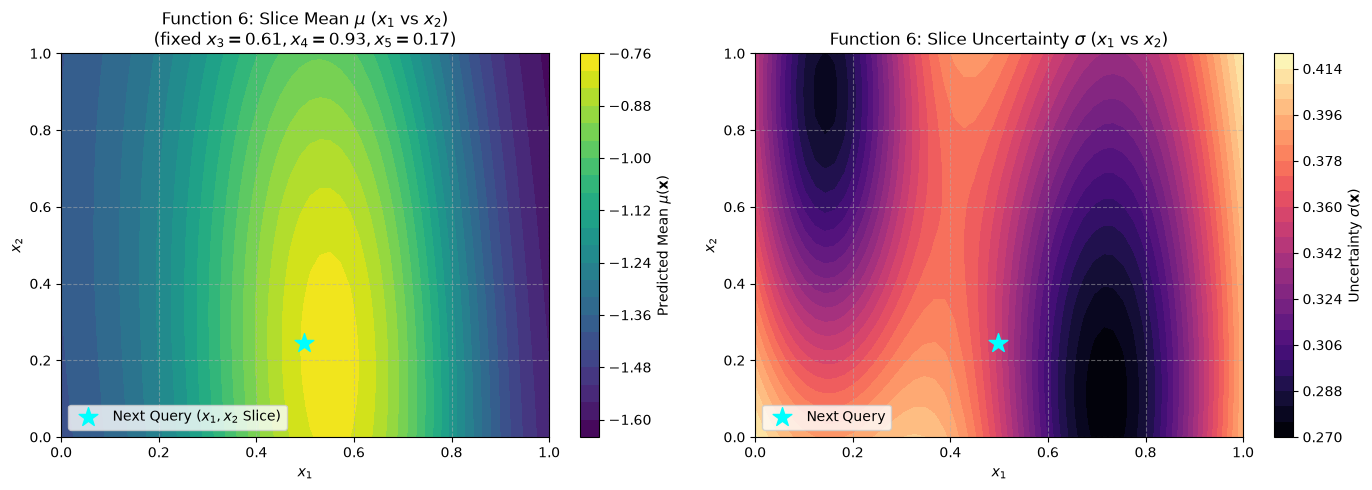

In [3]:
# ==========================================
# 2D ORTHOGONAL SLICE PROJECTIONS VISUALISATION (5D MODEL)
# ==========================================
grid_res = 50
s1_grid = np.linspace(0, 1, grid_res)
s2_grid = np.linspace(0, 1, grid_res)
S1_m, S2_m = np.meshgrid(s1_grid, s2_grid)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Construct test array varying x1 and x2, holding x3, x4, x5 fixed at next_query values
X_slice = np.column_stack([
    S1_m.ravel(), 
    S2_m.ravel(), 
    np.full(S1_m.size, next_query[2]), 
    np.full(S1_m.size, next_query[3]),
    np.full(S1_m.size, next_query[4])
])

mu_slice, sigma_slice = gp.predict(X_slice, return_std=True)
MU_grid = mu_slice.reshape(grid_res, grid_res)
SIG_grid = sigma_slice.reshape(grid_res, grid_res)

# Panel 1: Posterior Mean Surface (x1 vs x2)
c1 = axes[0].contourf(S1_m, S2_m, MU_grid, levels=25, cmap='viridis')
fig.colorbar(c1, ax=axes[0], label='Predicted Mean $\mu(\mathbf{x})$')
axes[0].scatter(next_query[0], next_query[1], color='cyan', marker='*', s=200, label='Next Query ($x_1, x_2$ Slice)')
axes[0].set_title(f'Function 6: Slice Mean $\mu$ ($x_1$ vs $x_2$)\n(fixed $x_3={next_query[2]:.2f}, x_4={next_query[3]:.2f}, x_5={next_query[4]:.2f}$)')
axes[0].set_xlabel('$x_1$')
axes[0].set_ylabel('$x_2$')
axes[0].legend(loc='lower left')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Panel 2: Epistemic Uncertainty Surface (x1 vs x2)
c2 = axes[1].contourf(S1_m, S2_m, SIG_grid, levels=25, cmap='magma')
fig.colorbar(c2, ax=axes[1], label='Uncertainty $\sigma(\mathbf{x})$')
axes[1].scatter(next_query[0], next_query[1], color='cyan', marker='*', s=200, label='Next Query')
axes[1].set_title(f'Function 6: Slice Uncertainty $\sigma$ ($x_1$ vs $x_2$)')
axes[1].set_xlabel('$x_1$')
axes[1].set_ylabel('$x_2$')
axes[1].legend(loc='lower left')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 2D feature pair slicer

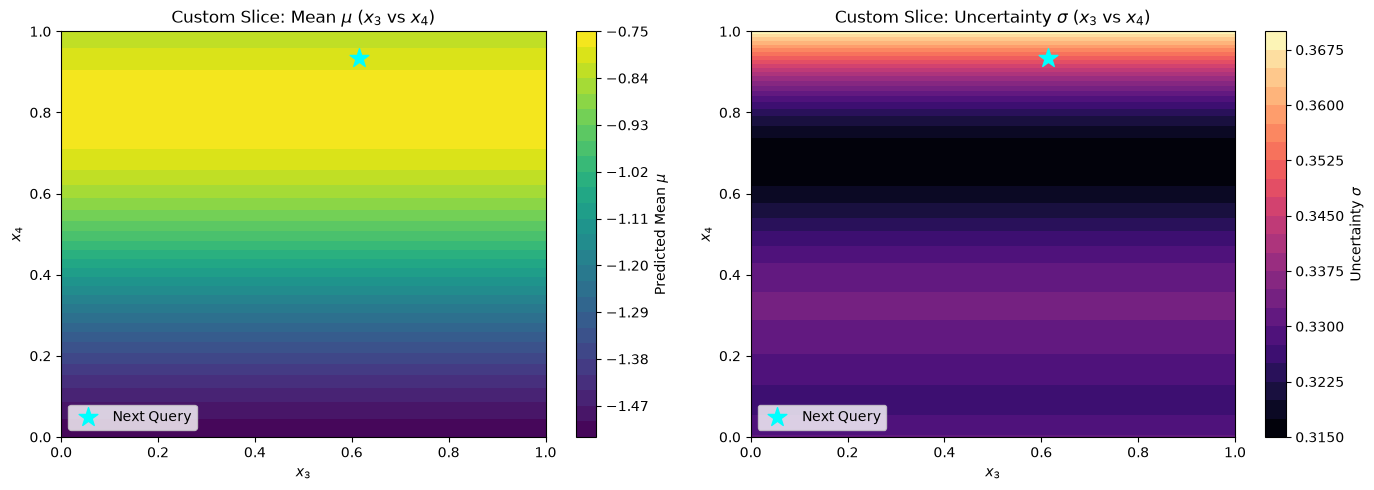

In [4]:
# ==========================================
# CUSTOM FEATURE PAIR SLICER FOR 5D/8D MODELS
# ==========================================
# Choose which two features to put on the X and Y axes of your plot
feat_x_idx = 2  # e.g., x3
feat_y_idx = 3  # e.g., x4

grid_res = 50
s1_grid = np.linspace(0, 1, grid_res)
s2_grid = np.linspace(0, 1, grid_res)
S1_m, S2_m = np.meshgrid(s1_grid, s2_grid)

# Create a full test array matching the model's total dimensionality (5 features)
# We start with a copy of the next query vector for all points
X_custom_slice = np.tile(next_query, (S1_m.size, 1))

# Overwrite the chosen columns with our 2D grid coordinates
X_custom_slice[:, feat_x_idx] = S1_m.ravel()
X_custom_slice[:, feat_y_idx] = S2_m.ravel()

# Predict mean and uncertainty across this custom slice plane
mu_custom, sigma_custom = gp.predict(X_custom_slice, return_std=True)
MU_c_grid = mu_custom.reshape(grid_res, grid_res)
SIG_c_grid = sigma_custom.reshape(grid_res, grid_res)

# Plotting the custom slice
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

c1 = axes[0].contourf(S1_m, S2_m, MU_c_grid, levels=25, cmap='viridis')
fig.colorbar(c1, ax=axes[0], label='Predicted Mean $\mu$')
axes[0].scatter(next_query[feat_x_idx], next_query[feat_y_idx], color='cyan', marker='*', s=200, label='Next Query')
axes[0].set_title(f'Custom Slice: Mean $\mu$ ($x_{feat_x_idx+1}$ vs $x_{feat_y_idx+1}$)')
axes[0].set_xlabel(f'$x_{feat_x_idx+1}$')
axes[0].set_ylabel(f'$x_{feat_y_idx+1}$')
axes[0].legend(loc='lower left')

c2 = axes[1].contourf(S1_m, S2_m, SIG_c_grid, levels=25, cmap='magma')
fig.colorbar(c2, ax=axes[1], label='Uncertainty $\sigma$')
axes[1].scatter(next_query[feat_x_idx], next_query[feat_y_idx], color='cyan', marker='*', s=200, label='Next Query')
axes[1].set_title(f'Custom Slice: Uncertainty $\sigma$ ($x_{feat_x_idx+1}$ vs $x_{feat_y_idx+1}$)')
axes[1].set_xlabel(f'$x_{feat_x_idx+1}$')
axes[1].set_ylabel(f'$x_{feat_y_idx+1}$')
axes[1].legend(loc='lower left')

plt.tight_layout()
plt.show()